In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from matplotlib.figure import Figure
from typing import Literal, Tuple

## Set directories

In [2]:
# set paths to experiment dirs
betabin_sweep_dirs = {
    'run1': Path('outputs/sweeps/sweep_cvae_cifar100_betabin_rs0'), # run_id: experiment_dir
    'run2': Path('outputs/sweeps/sweep_cvae_cifar100_betabin_rs1'),
    'run3': Path('outputs/sweeps/sweep_cvae_cifar100_betabin_rs2'),
}

binom_sweep_dirs = {
    'run1': Path('outputs/sweeps/sweep_cvae_cifar100_binom_rs0'),
    'run2': Path('outputs/sweeps/sweep_cvae_cifar100_binom_rs1'),
    'run3': Path('outputs/sweeps/sweep_cvae_cifar100_binom_rs2'),
}

# outputs
out_dir = Path('outputs/performance')

## Calculate performance

In [3]:
def combine_eval_df(sweep_dirs: dict[int, Path]) -> pd.DataFrame:
    dataframes = []
    target_columns = ['node_id', 'alpha', 'beta', 'mean_activation', 'run_id', 'rmse', 'fid']
    # collect eval summaries
    for run_id, experiment_path in sweep_dirs.items():
        file_path = experiment_path / 'eval_summary.csv'
        if file_path.exists():
            df = pd.read_csv(file_path)
            df['run_id'] = run_id
            df_filtered = df[target_columns]
            dataframes.append(df_filtered)
        else:
            raise FileNotFoundError(f'{file_path} does not exist')
    combined_df = pd.concat(dataframes, ignore_index=True)
    
    # average over runs
    avg_df = combined_df.groupby('node_id').agg({
        'rmse': 'mean',
        'fid': 'mean',
        'alpha': 'first',
        'beta': 'first',
        'mean_activation': 'first'
    }).reset_index()
    avg_df['run_id'] = 'avg'
    avg_df = avg_df[target_columns] # order columns
    
    # concatenate
    combined_df = pd.concat([combined_df, avg_df], ignore_index=True)
    
    return combined_df

In [4]:
# combine
betabin_eval_df = combine_eval_df(betabin_sweep_dirs)
binom_eval_df = combine_eval_df(binom_sweep_dirs)

betabin_eval_df.head()

,node_id,alpha,beta,mean_activation,run_id,rmse,fid
0,0,0.225,0.225,0.60400,run1,0.129580,294.938268
1,1,0.675,0.225,0.75969,run1,0.130221,298.044966
2,2,1.125,0.225,0.83461,run1,0.129272,297.792214
3,3,1.575,0.225,0.87483,run1,0.129352,297.290768
4,4,2.025,0.225,0.90081,run1,0.129862,297.140515


In [5]:
def get_performance_df(
        betabin_eval_df: pd.DataFrame,
        binom_eval_df: pd.DataFrame
) -> pd.DataFrame:
    # helper
    def _eval_df_to_performance_df(eval_df, max_fid):
        return eval_df.assign(
            fidelity_score = 1 - eval_df['rmse'],
            generalization_score = max_fid - eval_df['fid']
        )
    
    target_columns = ['node_id', 'alpha', 'beta', 'mean_activation', \
        'run_id', 'fidelity_score', 'generalization_score']
    max_fid = max(
        betabin_eval_df['fid'].max(),
        binom_eval_df['fid'].max()
    )
    betabin_perf_df = _eval_df_to_performance_df(betabin_eval_df, max_fid)[target_columns]
    binom_perf_df = _eval_df_to_performance_df(binom_eval_df, max_fid)[target_columns]
    return {
        "betabin": betabin_perf_df,
        "binom": binom_perf_df
    }

In [6]:
# calculate performance
performance_dfs = get_performance_df(betabin_eval_df, binom_eval_df)

# save performance
performance_dfs['betabin'].to_csv(out_dir / 'betabin_performance.csv', index=False)
performance_dfs['binom'].to_csv(out_dir / 'binom_performance.csv', index=False)

## Draw heatmaps

In [7]:
# helper
from src.visualization.sweep.heatmap import plot_sweep_heatmap

plan = np.load(betabin_sweep_dirs['run1'] / 'sweep_plan.npz')
node_centers = plan['node_centers']
node_sizes = plan['node_sizes']

def plot_performance(
    performance: Literal['fidelity', 'generalization', 'cost'],
    selectivity: Literal['betabin', 'binom', 'improvement'],
    run_id: Literal['avg', 'run1', 'run2', 'run3'],
    clim: Tuple[float, float] | None = None,
    cmap: str = 'Oranges_r'
) -> Figure:
    global performance_dfs
    if performance == 'cost':
        perf_type = 'mean_activation'
        perf_name = 'cost'
    else:
        perf_type = f'{performance}_score'
        perf_name = f'{performance} score'
    
    def get_perf_vals(selectivity):
        perf_df = performance_dfs[selectivity]
        return perf_df.loc[
            perf_df['run_id'] == run_id, perf_type
        ]
    
    if selectivity == 'improvement':
        perf_values = get_perf_vals('betabin') - get_perf_vals('binom')
    else:
        perf_values = get_perf_vals(selectivity)
    
    return plot_sweep_heatmap(
        node_centers = node_centers,
        node_sizes = node_sizes,
        node_values = perf_values,
        value_name = perf_name,
        title = f'{perf_name} ({selectivity})',
        clim = clim,
        fig_size = (3,3),
        cmap = cmap
    )

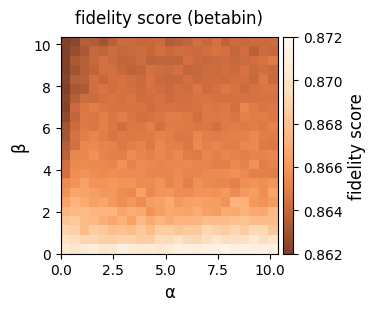

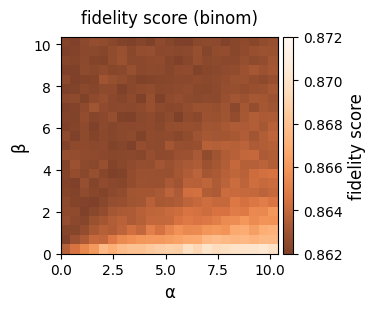

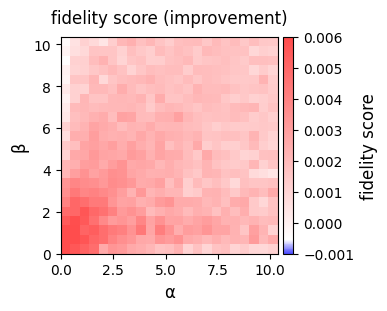

In [8]:
# Fidelity score
fig1 = plot_performance(performance='fidelity', selectivity='betabin', run_id='avg', clim=(0.862, 0.872), cmap='Oranges_r')
fig2 = plot_performance(performance='fidelity', selectivity='binom', run_id='avg', clim=(0.862, 0.872), cmap='Oranges_r')
fig3 = plot_performance(performance='fidelity', selectivity='improvement', run_id='avg', clim=(-0.001, 0.006), cmap='BlWtRd')

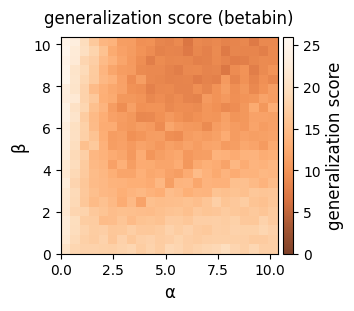

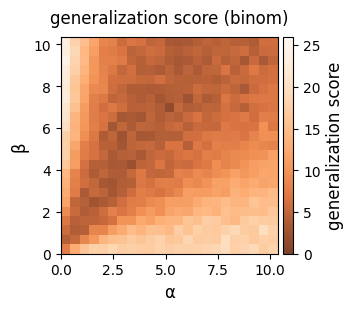

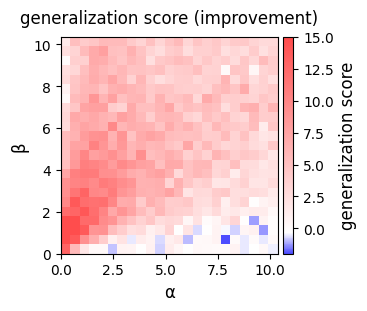

In [9]:
# Generalization score
fig1 = plot_performance(performance='generalization', selectivity='betabin', run_id='avg', clim=(0.0, 25.97), cmap='Oranges_r')
fig2 = plot_performance(performance='generalization', selectivity='binom', run_id='avg', clim=(0.0, 25.97), cmap='Oranges_r')
fig3 = plot_performance(performance='generalization', selectivity='improvement', run_id='avg', clim=(-2, 15), cmap='BlWtRd')

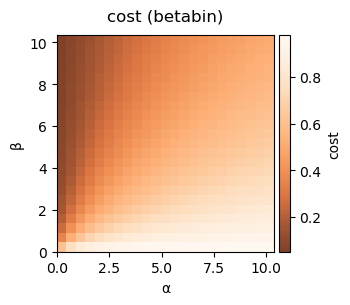

In [10]:
# Cost
fig = plot_performance(performance='cost', selectivity='betabin', run_id='avg', cmap='Oranges_r')

## Visualize distribution shapes in the α-β parameter space

In [10]:
from src.configs import get_sweep_config
from src.visualization import plot_sweep_distributions, COLORS

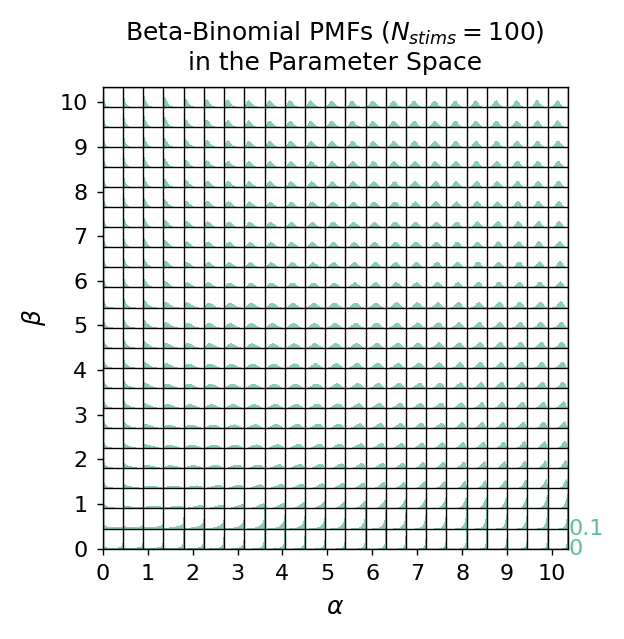

In [11]:
n_classes = 100

# betabin
sweep_cfg = get_sweep_config(betabin_sweep_dirs['run1'] / 'sweep_config.json')
fig1 = plot_sweep_distributions(
    mode = 'betabin', n_classes = n_classes,
    w_steps = sweep_cfg.n_nodes[0],
    h_steps = sweep_cfg.n_nodes[1],
    max_alpha = sweep_cfg.range_alpha[1],
    max_beta = sweep_cfg.range_beta[1],
    cell_ylim = 0.10, fig_size = (3, 3),
    font_size = 8, line_width_scaling = 0.5,
    distribution_color = COLORS['light-green'],
    dpi = 200
)

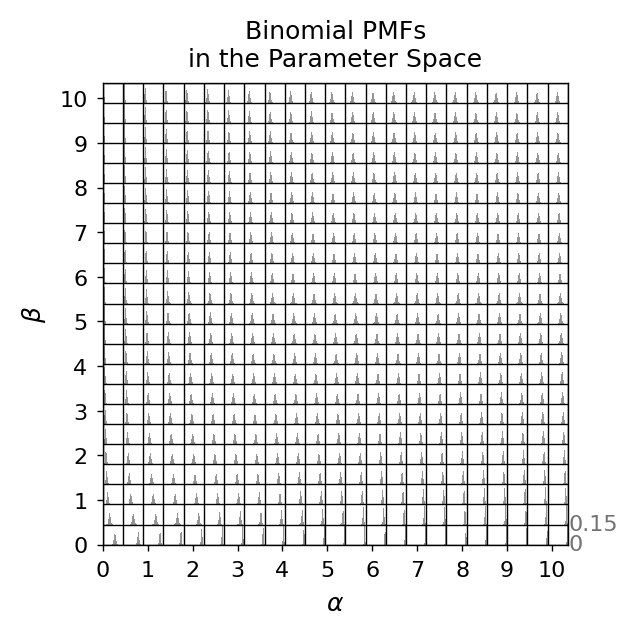

In [12]:
# binom
sweep_cfg = get_sweep_config(binom_sweep_dirs['run1'] / 'sweep_config.json')
fig2 = plot_sweep_distributions(
    mode = 'binom', n_classes = n_classes,
    w_steps = sweep_cfg.n_nodes[0],
    h_steps = sweep_cfg.n_nodes[1],
    max_alpha = sweep_cfg.range_alpha[1],
    max_beta = sweep_cfg.range_beta[1],
    cell_ylim = 0.15, fig_size = (3, 3),
    font_size = 8, line_width_scaling = 0.5,
    distribution_color = COLORS['gray'],
    dpi = 200
)